# Part 2 — Data → model: predict every shape

> **Extra, read only.** This lecture notebook is kept with its saved outputs. It ran with anemoi-training 0.17 and anemoi-inference 0.12 on the lecture dataset, not with the course kernel, so read it but do not rerun it in class.

**Question:** what happens to one training sample between `ds[i:i+3]` and the loss? **Slides 4–14.**
**Exercise:** write every shape down before its cell prints it: `(2, 3, 1, 10944, 43)` → `(2562, 128)` → `(10944, 30)`.
**Needs:** the course zip, `graph/graph_o48_tri4.pt`, `checkpoints/course-o48-gt128.ckpt` (runbook Phases 1–4); one GPU.
**Tags:** `# RUN` execute now · `# REVIEW` shown in the 30-minute review · `# SAVED` reads a runbook file.

In [1]:
# RUN — paths, imports, quiet warnings
import os
import json
import zipfile
import subprocess
import warnings
import logging
from pathlib import Path

import numpy as np
import yaml
import torch
import matplotlib.pyplot as plt
from anemoi.datasets import open_dataset
import anemoi.training

warnings.filterwarnings("ignore")                          # hide library deprecation notices
logging.disable(logging.WARNING)                           # keep the cells quiet
plt.rcParams["figure.dpi"] = 80                            # small figures

# where things are: <repo>/data/anemoi-course, or the folder named in ANEMOI_COURSE_BASE
BASE = Path(os.environ.get("ANEMOI_COURSE_BASE", "../../../data/anemoi-course")).resolve()
DATA = BASE / "data" / "era5-o48-2020-2021-6h-v1.zip"     # the course dataset (a zipped zarr)
GRAPH = BASE / "graph" / "graph_o48_tri4.pt"               # the graph built in the runbook (Phase 2)
CK = BASE / "checkpoints" / "course-o48-gt128.ckpt"        # the trained course model (Phase 4)
PKG_CFG = Path(anemoi.training.__file__).parent / "config" # the Hydra config groups shipped with anemoi-training (Part 3)

for name, path in [("dataset", DATA), ("graph", GRAPH), ("checkpoint", CK)]:
    if path.exists():
        status = "ok"
    else:
        status = "MISSING"
    print(f"{name:10s} {status:7s} {path}")

dataset    ok      /gpfs/scratch/bsc32/bsc437208/anemoi-course/data/era5-o48-2020-2021-6h-v1.zip
graph      ok      /gpfs/scratch/bsc32/bsc437208/anemoi-course/graph/graph_o48_tri4.pt
checkpoint ok      /gpfs/scratch/bsc32/bsc437208/anemoi-course/checkpoints/course-o48-gt128.ckpt


**Expected:** three `ok` lines.

## 1 · The state tensor (slide 4)

`data[t, v, e, i]`: date, variable, ensemble member, grid point. Predict: `ds.shape = ( , , , )`, `ds[100].shape = ( , , )`.

In [2]:
# REVIEW — inspect reads metadata and statistics; open_dataset adds the array
command = ["anemoi-datasets", "inspect", str(DATA)]                 # the command-line tool of anemoi-datasets
result = subprocess.run(command, capture_output=True, text=True)
inspect_lines = result.stdout.splitlines()                          # one line per row of the inspect report

keys = ("Date", "Frequency", "Resolution", "Shape", "│ 2t ", "│ q_1000", "│ z_500")   # the rows worth reading
for line in inspect_lines:
    for key in keys:
        if key in line:
            print(line)
            break

ds = open_dataset(DATA)                                             # the dataset object: lazy, nothing is read yet
X_t = ds[100]                                                       # the state at date number 100: this reads from disk
print()
print("ds.shape        ", ds.shape)
print("ds[100].shape   ", X_t.shape, " at", ds.dates[100])
print("ds.variables[:4]", ds.variables[:4])
print("grid            ", ds.latitudes.shape, " flat: one index per point")
z500 = ds.name_to_index["z_500"]                                    # the column of z_500 on the variable axis
stdev_z500 = ds.statistics["stdev"][z500]                           # the dataset's own standard deviation of z_500
print("stdev of z_500  ", f"{stdev_z500:.3g}")

📅 Date      start: 2020-01-01 00:00
📅 Date      end  : 2021-12-31 18:00
⏰ Frequency  : 6h
🌎 Resolution : O48
📐 Shape      : 2,924 × 43 × 1 × 10,944 (5.1 GiB)
│     3 │ 2t             │       195 │      326 │       288 │     16.1 │ -     │
│    12 │ q_1000         │     1e-08 │   0.0294 │   0.00963 │  0.00588 │ -     │
│    41 │ z_500          │  4.37e+04 │ 5.89e+04 │  5.56e+04 │ 2.82e+03 │ -     │



ds.shape         (2924, 43, 1, 10944)
ds[100].shape    (43, 1, 10944)  at 2020-01-26T00:00:00
ds.variables[:4] ['10u', '10v', '2d', '2t']
grid             (10944,)  flat: one index per point
stdev of z_500   2.82e+03


**Expected:** `2,924 × 43 × 1 × 10,944`, `6h`; `ds[100].shape = (43, 1, 10944)`; stdev of `z_500` = 2.82e+03.
Indexing a date removes the time axis; the ensemble axis of length 1 stays.

## 2 · One sample, as the model receives it (slides 5, 6)

Three dates cut from `ds`, stacked in loader order, then normalised with the dataset's own μ, σ. Predict: `ds[i:i+3]` = ( , , , ); a batch of two = ( , , , , ).

In [3]:
# RUN — window, loader order, normaliser (packaged data/zarr.yaml policy, dataset statistics)
from omegaconf import OmegaConf
from anemoi.models.data_indices.collection import IndexCollection
from anemoi.models.preprocessing.normalizer import InputNormalizer

task = yaml.safe_load(open(PKG_CFG / "task" / "forecaster.yaml"))          # how many dates one sample holds
data_cfg = OmegaConf.load(PKG_CFG / "data" / "zarr.yaml").datasets.data     # forcing, diagnostic, normalizer policy
indices = IndexCollection(data_cfg, ds.name_to_index)                       # which columns are input, output, forcing, ...
normalizer = InputNormalizer(config=data_cfg.processors.normalizer.config, data_indices=indices, statistics=ds.statistics)

i = 100                                                                     # the first date of the window
window = np.asarray(ds[i:i + 3])                                            # three dates: (time, variable, ensemble, grid)
window_next = np.asarray(ds[i + 1:i + 4])                                   # the window that starts one date later
stacked = np.stack([window, window_next])                                   # a batch of two: (batch, time, variable, ensemble, grid)
batch = torch.as_tensor(np.moveaxis(stacked, 2, -1))                        # the loader order: variables last
dates = ds.dates[i:i + 3].astype("datetime64[h]")                         # the three dates, to the hour
print("dates    ", dates)
print("ds[i:i+3]", window.shape, "→ loader batch", tuple(batch.shape), "(batch, time, ensemble, grid, variables)")

n_input = task["multistep_input"]                                           # dates the model reads
n_rollout = task["rollout"]["maximum"]                                      # steps it predicts in a row
n_output = task["multistep_output"]                                         # dates per step
n_dates = n_input + n_rollout * n_output
print("multistep_input", n_input, "+ rollout.maximum", n_rollout, "× multistep_output", n_output, "=", n_dates, "dates per sample")

normalised = normalizer(batch, in_place=False)                              # (x − μ) / σ per variable, with the policy of zarr.yaml
z = ds.name_to_index["z_500"]
tp = ds.name_to_index["tp"]
z_raw = batch[..., z]                                                       # z_500 before normalising
z_norm = normalised[..., z]                                                 # and after
print(f"z_500  {z_raw.min():.4g} … {z_raw.max():.4g}  →  {z_norm.min():.2f} … {z_norm.max():.2f}")
dry = batch[..., tp] == 0                                                   # True where no rain fell
n_dry = int(dry.sum())
still_zero = bool((normalised[..., tp][dry] == 0).all())                    # the 'std' policy only divides, so 0 stays 0
print(f"tp     {n_dry} dry points, still exactly 0 after the 'std' policy: {still_zero}")

dates     ['2020-01-26T00' '2020-01-26T06' '2020-01-26T12']
ds[i:i+3] (3, 43, 1, 10944) → loader batch (2, 3, 1, 10944, 43) (batch, time, ensemble, grid, variables)
multistep_input 2 + rollout.maximum 1 × multistep_output 1 = 3 dates per sample
z_500  4.795e+04 … 5.838e+04  →  -2.73 … 0.97
tp     17657 dry points, still exactly 0 after the 'std' policy: True


**Expected:** `(3, 43, 1, 10944)` → `(2, 3, 1, 10944, 43)`; 2 + 1 × 1 = 3 dates; `z_500` lands within a few units of 0; dry points stay 0.
The two samples share two dates, which is why validation is split by period (section 4).

## 3 · Variable roles (slide 7)

Two lists in the configuration (`forcing`, `diagnostic`) split the 43 variables into P, F, D. Predict: |P|, |F|, |D|, input width, output width.

In [4]:
# REVIEW — which variables go in, which come out
forcing = list(data_cfg.forcing)                                    # F: known inputs, never predicted (angles, orography, ...)
diagnostic = list(data_cfg.diagnostic)                              # D: predicted outputs, never fed back (tp, cp)
prognostic = []                                                     # P: everything else, read in and predicted
for name in ds.variables:
    if name not in forcing and name not in diagnostic:
        prognostic.append(name)
print(f"prognostic {len(prognostic)} | forcing {len(forcing)} | diagnostic {len(diagnostic)}")
print("forcing   ", forcing)
print("diagnostic", diagnostic)

x_in = normalised[:, :n_input][..., indices.data.input.full]        # the first two dates, input columns only: what the model reads
y = normalised[:, n_input:][..., indices.data.output.full]          # the last date, output columns only: what it must predict
n_in_prog = len(indices.model.input.prognostic)
n_in_forc = len(indices.model.input.forcing)
n_out_prog = len(indices.model.output.prognostic)
n_out_diag = len(indices.model.output.diagnostic)
width_in = x_in.shape[-1]                                           # variables per grid point going in
width_out = y.shape[-1]                                             # variables per grid point coming out
print(f"input  {tuple(x_in.shape)}  {n_in_prog} prognostic + {n_in_forc} forcing = {width_in}, × 2 states = {2 * width_in} per grid point")
print(f"output {tuple(y.shape)}  {n_out_prog} prognostic + {n_out_diag} diagnostic = {width_out}")

prognostic 28 | forcing 13 | diagnostic 2
forcing    ['cos_latitude', 'cos_longitude', 'sin_latitude', 'sin_longitude', 'cos_julian_day', 'cos_local_time', 'sin_julian_day', 'sin_local_time', 'insolation', 'lsm', 'sdor', 'slor', 'z']
diagnostic ['tp', 'cp']
input  (2, 2, 1, 10944, 41)  28 prognostic + 13 forcing = 41, × 2 states = 82 per grid point
output (2, 1, 1, 10944, 30)  28 prognostic + 2 diagnostic = 30


**Expected:** 28 / 13 / 2; input `(2, 2, 1, 10944, 41)` → 82 values per grid point; output `(2, 1, 1, 10944, 30)`.
Only the 28 prognostic outputs are fed back into the next step; `tp`, `cp` are predicted and dropped.

> **Checkpoint:** `skt` moves to `forcing` — new input width, new output width, and what happens to `skt` during a forecast?

## 4 · Training, validation and test periods (slide 8)

Same `start` / `end` keys as `dataloader.*.datasets.data`. Predict: dates in 2020, in 2021-01→06, in 2021-07→12.

In [5]:
# RUN — the three periods, and the statistics window that overlaps validation
periods = [("training", None, 2020), ("validation", "2021-01", "2021-06"), ("test", "2021-07", None)]   # name, start, end
for name, start, end in periods:
    part = open_dataset(DATA, start=start, end=end)                 # the same keys as dataloader.<name>.datasets.data
    n_dates = len(part)
    first = part.dates[0]
    last = part.dates[-1]
    print(f"{name:11s} start={start!s:8s} end={end!s:8s} → {n_dates:5d} dates  {first} … {last}")

attrs = json.loads(zipfile.ZipFile(DATA).read(".zattrs"))          # the zarr attributes, read straight from the zip
stats_start = attrs["statistics_start_date"][:10]                   # the dates μ and σ were computed on
stats_end = attrs["statistics_end_date"][:10]
print("statistics window", stats_start, "→", stats_end)

training    start=None     end=2020     →  1464 dates  2020-01-01T00:00:00 … 2020-12-31T18:00:00


validation  start=2021-01  end=2021-06  →   724 dates  2021-01-01T00:00:00 … 2021-06-30T18:00:00
test        start=2021-07  end=None     →   736 dates  2021-07-01T00:00:00 … 2021-12-31T18:00:00
statistics window 2020-01-01 → 2021-08-07


**Expected:** 1,464 / 724 / 736; `end` is inclusive; statistics 2020-01-01 → 2021-08-07 overlap validation.
A random split would put the target of one training window into validation as an input.

## 5 · The graph (slide 9)

$G = (V_{data} \cup V_{hidden},\; E_{enc} \cup E_{proc} \cup E_{dec})$ from `graph/graph_o48_tri4.pt`. Predict: hidden nodes at $r = 4$ (10·4⁴ + 2), decoder edges (3 × 10 944).

In [6]:
# REVIEW — node sets, edge sets, in-degrees
graph = torch.load(GRAPH, map_location="cpu", weights_only=False)   # a PyTorch Geometric HeteroData object
for nodes in graph.node_types:                                      # "data" and "hidden"
    coordinates = graph[nodes].x                                    # one (lat, lon) row per node
    print(f"{nodes:7s} x {tuple(coordinates.shape)}  (lat, lon in radians)")
for src, _, dst in graph.edge_types:                                # data→hidden, hidden→hidden, hidden→data
    edge_index = graph[src, "to", dst].edge_index                   # row 0 = source node, row 1 = target node
    n_edges = edge_index.shape[1]
    in_degree = np.bincount(edge_index[1].numpy())                  # how many edges arrive at each target node
    print(f"{src}→{dst:7s} {n_edges:6d} edges, {in_degree.min()}–{in_degree.max()} per target node")

from anemoi.graphs.nodes import TriNodes
hidden_by_r = {}                                                    # nodes of the icosahedral mesh at each refinement level
for r in (3, 4, 5, 6):
    coordinates = TriNodes(resolution=r, name="hidden").get_coordinates()
    hidden_by_r[r] = coordinates.shape[0]
print("hidden nodes by refinement r:", hidden_by_r)

data    x (10944, 2)  (lat, lon in radians)
hidden  x (2562, 2)  (lat, lon in radians)
data→hidden   16964 edges, 4–20 per target node
hidden→hidden   20400 edges, 6–24 per target node
hidden→data     32832 edges, 3–3 per target node


hidden nodes by refinement r: {3: 642, 4: 2562, 5: 10242, 6: 40962}


**Expected:** data 10,944, hidden 2,562; edges 16,964 (4–20) / 20,400 (6–24) / 32,832 (exactly 3); 642 / 2,562 / 10,242 / 40,962 by $r$.
Only the kNN decoder has a constant in-degree: every output point gets three parents; the cut-off encoder drops no data point.

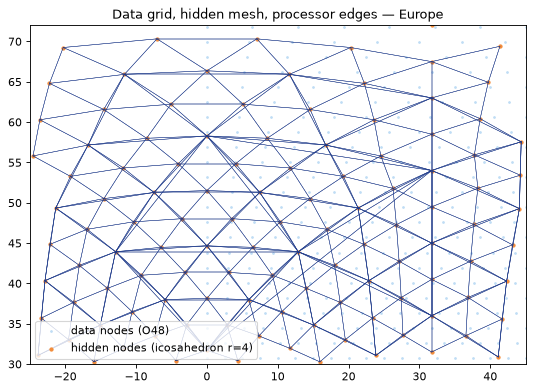

In [7]:
# REVIEW — the hidden mesh over Europe: data nodes, hidden nodes, processor edges
data_deg = np.degrees(graph["data"].x.numpy())                      # (lat, lon) of every data node, in degrees
hidden_deg = np.degrees(graph["hidden"].x.numpy())                  # the same for the hidden nodes
lon_min = -25                                                       # the box around Europe, in degrees
lon_max = 45
lat_min = 30
lat_max = 72


def in_box(point):
    # True when a (lat, lon) point lies inside the Europe box
    lat = point[0]
    lon = point[1]
    return lon_min < lon < lon_max and lat_min < lat < lat_max


fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(data_deg[:, 1], data_deg[:, 0], s=2, c="#BFDDF5", label="data nodes (O48)")      # one dot per grid point
processor_edges = graph["hidden", "to", "hidden"].edge_index.numpy().T                     # one (source, target) pair per row
for source, target in processor_edges:
    if in_box(hidden_deg[source]) and in_box(hidden_deg[target]):                           # draw only the edges inside the box
        lons = [hidden_deg[source, 1], hidden_deg[target, 1]]
        lats = [hidden_deg[source, 0], hidden_deg[target, 0]]
        ax.plot(lons, lats, c="#1E3A8A", lw=0.4)
ax.scatter(hidden_deg[:, 1], hidden_deg[:, 0], s=8, c="#F28C3B", label="hidden nodes (icosahedron r=4)")
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_title("Data grid, hidden mesh, processor edges — Europe")
ax.legend(loc="lower left")
fig.savefig("assets/mesh_europe.png", dpi=80, bbox_inches="tight")

**Expected:** a map of Europe: light-blue data points, orange hidden nodes, dark-blue processor edges between them.

> **Checkpoint:** why cut-off edges for the encoder and k-nearest-neighbour edges for the decoder?

## 6 · One layer, then the whole forward pass (slides 10–12)

A layer is **message** per edge → **sum** per target node → **residual update**; attention (slide 11) only changes how the sum is weighted.
Predict: latent after the encoder ( , ), after 16 processor blocks ( , ), decoder output ( , ).

![message](assets/message_schema.png)
![aggregate and update](assets/agg_update_schema.png)

In [8]:
# REVIEW — load the course model on the GPU and name its three stages
from anemoi.inference.config.run import RunConfiguration
from anemoi.inference.runners import create_runner

config = RunConfiguration(checkpoint=str(CK), date="2021-07-01T00:00:00", lead_time=6,
                          input={"dataset": str(DATA)}, output="none", device="cuda", verbosity=0)
runner = create_runner(config)                                      # loads the checkpoint and prepares the input state
net = runner.model.model                                            # the AnemoiModelEncProcDec inside the checkpoint
stages = {
    "encoder": net.encoder["0"],      # gets data features (10944, 94) + hidden features (2562, 12); returns both, hidden side now 128 wide
    "processor": net.processor,       # gets the latent (2562, 128); returns it, same shape, after 16 blocks
    "decoder": net.decoder["0"],      # gets the latent + the data features; returns the 30 outputs per grid point
}
device = next(net.parameters()).device                              # where the weights live
print(type(net).__name__, "on", device)


def shape_of(tensors):
    # the shape of one tensor, or the list of shapes when a stage passes several tensors
    if torch.is_tensor(tensors):
        return tuple(tensors.shape)
    shapes = []
    for tensor in tensors:
        shapes.append(tuple(tensor.shape))
    return shapes


def print_shapes(module, args, kwargs, output):
    # a forward hook: PyTorch calls it after the module has run, with what went in and what came out
    name = stage_names[module]                                      # which stage this module is
    if args:
        inputs = args[0]                                            # the stage received its tensors positionally ...
    else:
        inputs = kwargs["x"]                                        # ... or as the keyword x
    print(f"{name:10s} in {shape_of(inputs)} → out {shape_of(output)}")

AnemoiModelEncProcDec on cuda:0


**Expected:** `AnemoiModelEncProcDec on cuda:0`; nothing runs yet — the hooks fire in the next cell.

In [9]:
# REVIEW — one 6 h step with a hook on each stage, then where the parameters are
stage_names = {}                                                    # module → its name, looked up by the hook
hooks = []                                                          # the handles, to remove the hooks afterwards
for name, module in stages.items():
    stage_names[module] = name
    hooks.append(module.register_forward_hook(print_shapes, with_kwargs=True))
runner.execute()                                                    # one 6 h step: encoder → processor → decoder
for hook in hooks:
    hook.remove()                                                   # leave the model as we found it

total = 0
for parameter in net.parameters():
    total = total + parameter.numel()                               # numel = how many numbers a weight tensor holds
processor_type = type(net.processor).__name__
n_blocks = len(net.processor.proc)                                  # the processor is a list of identical blocks
print()
print(f"{type(net).__name__}: {total:,} parameters; processor = {processor_type}, {n_blocks} blocks")
for name, module in stages.items():
    n = 0
    for parameter in module.parameters():
        n = n + parameter.numel()
    share = 100 * n / total                                         # in percent
    print(f"  {name:10s} {n:>10,}  ({share:4.1f} %)")

encoder    in [(10944, 94), (2562, 12)] → out [(10944, 94), (2562, 128)]
processor  in (2562, 128) → out (2562, 128)
decoder    in [(2562, 128), (10944, 94)] → out (10944, 30)

AnemoiModelEncProcDec: 4,593,998 parameters; processor = GraphTransformerProcessor, 16 blocks
  encoder       230,400  ( 5.0 %)
  processor   3,461,120  (75.3 %)
  decoder       232,862  ( 5.1 %)


**Expected:** encoder `(10944, 94)` + `(2562, 12)` → `(2562, 128)`; processor keeps `(2562, 128)`; decoder → `(10944, 30)`; about three quarters of the parameters sit in the processor.
The 28 prognostic outputs are increments added to $X_t$, so the untrained model already returns persistence.

## 7 · The loss weights (slide 13)

$\mathcal L = \frac1R\sum_r \sum_v w_v\,\ell(p_v) \sum_i a_i (\tilde{\hat x}_{i,v} - \tilde x_{i,v})^2$ in normalised space. Predict: the heaviest and the lightest of the 30 outputs.

In [10]:
# RUN — general_variable × pressure_level per output variable, and the area weights
scalers = yaml.safe_load(open(PKG_CFG / "training" / "scalers" / "global.yaml"))["datasets"]["data"]
variable_weight = scalers["general_variable"]["weights"]            # w_v: one weight per variable name, plus a default
level = scalers["pressure_level"]                                   # l(p) = max(y_intercept, slope · p)
print("general_variable:", variable_weight)


def level_weight(pressure):
    # the pressure-level factor l(p): heavier near the surface, floored at y_intercept
    return max(level["y_intercept"], level["slope"] * pressure)


examples = {}
for pressure in (1000, 500, 200, 50):
    examples[pressure] = level_weight(pressure)
print(f"pressure_level  : max({level['y_intercept']}, {level['slope']}·p) →", examples)

weights = []                                                        # (w_v · l(p), name) for each of the 30 outputs
for name in prognostic + diagnostic:
    base, _, pressure = name.partition("_")                         # "z_500" → base "z", pressure "500"; "2t" → base "2t", pressure ""
    if pressure:
        w = variable_weight.get(base, variable_weight["default"])   # upper-air variable: the weight of its base name
        l = level_weight(int(pressure))
    else:
        w = variable_weight.get(name, variable_weight["default"])   # surface variable: the weight of its own name
        l = 1.0
    weights.append((w * l, name))
heaviest = sorted(weights)[::-1][:3]                                # the three largest products
lightest = sorted(weights)[:2]                                      # the two smallest
for product, name in heaviest + lightest:
    print(f"  {name:7s} w_v·l(p) = {product:.4f}")
area = graph["data"]["area_weight"].squeeze()                       # a_i: one weight per data node, stored in the graph file
print(f"node_weights: area_weight {area.min():.2f} … {area.max():.2f}, normalised to sum 1 in the loss")

general_variable: {'default': 1, 'q': 0.6, 't': 6, 'u': 0.8, 'v': 0.5, 'w': 0.001, 'z': 12, 'sp': 10, '10u': 0.1, '10v': 0.1, '2d': 0.5, 'tp': 0.025, 'cp': 0.0025}
pressure_level  : max(0.2, 0.001·p) → {1000: 1.0, 500: 0.5, 200: 0.2, 50: 0.2}
  z_1000  w_v·l(p) = 12.0000
  z_850   w_v·l(p) = 10.2000
  sp      w_v·l(p) = 10.0000
  cp      w_v·l(p) = 0.0025
  tp      w_v·l(p) = 0.0250
node_weights: area_weight 0.21 … 1.00, normalised to sum 1 in the loss


**Expected:** `z_1000` 12.0, `z_850` 10.2, `sp` 10.0 … `tp` 0.025, `cp` 0.0025; $\ell(p)$ = 1.0 / 0.5 / 0.2 / 0.2; area weights 0.21 … 1.
Slide 14: every number above scales to AIFS by changing configuration values, not code — that is Part 3.